In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Reload all datasets into a dictionary of DataFrames

RAW_DATA_PATH = "C:\\Users\\vsmuh\\Downloads\\Project 1\\data\\raw"

files = {
    "demographics"  : "DEMO_J.XPT",
    "body_measures" : "BMX_J.XPT",
    "hba1c"         : "GHB_J.XPT",
    "diabetes_q"    : "DIQ_J.XPT",
    "blood_pressure": "BPX_J.XPT",
    "cholesterol"   : "TCHOL_J.XPT"
}

dataframes = {}
for name, filename in files.items():
    filepath = os.path.join(RAW_DATA_PATH, filename)
    df = pd.read_sas(filepath, format='xport', encoding='utf-8')
    dataframes[name] = df
print("All datasets reloaded successfully!")

c:\Users\vsmuh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All datasets reloaded successfully!


# Exploratory data analysis (EDA) for the diabetes dataset

In [9]:
     # Peek at Each Dataset
for name, df in dataframes.items():
    print(f"\n{'='*50}")
    print(f"📋 {name.upper()}")
    print(f"{'='*50}")
    print(df.head(3))



📋 DEMOGRAPHICS
      SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  93703.0      10.0       2.0       2.0       2.0       NaN       5.0   
1  93704.0      10.0       2.0       1.0       2.0       NaN       3.0   
2  93705.0      10.0       2.0       2.0      66.0       NaN       4.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  DMDHREDZ  DMDHRMAZ  DMDHSEDZ  \
0       6.0       2.0      27.0  ...       3.0       1.0       3.0   
1       3.0       1.0      33.0  ...       3.0       1.0       2.0   
2       4.0       2.0       NaN  ...       1.0       2.0       NaN   

       WTINT2YR      WTMEC2YR  SDMVPSU  SDMVSTRA  INDHHIN2  INDFMIN2  INDFMPIR  
0   9246.491865   8539.731348      2.0     145.0      15.0      15.0      5.00  
1  37338.768343  42566.614750      1.0     143.0      15.0      15.0      5.00  
2   8614.571172   8338.419786      2.0     145.0       3.0       3.0      0.82  

[3 rows x 46 columns]

📋 BODY_MEASURES
      SEQN  BMDSTATS  BMXWT  BMIWT  BMXREC

In [10]:
   #Check Column Names
for name, df in dataframes.items():
    print(f"\n📋 {name.upper()} columns:")
    print(list(df.columns))


📋 DEMOGRAPHICS columns:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMQADFC', 'DMDBORN4', 'DMDCITZN', 'DMDYRSUS', 'DMDEDUC3', 'DMDEDUC2', 'DMDMARTL', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ', 'DMDFMSIZ', 'DMDHHSZA', 'DMDHHSZB', 'DMDHHSZE', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVPSU', 'SDMVSTRA', 'INDHHIN2', 'INDFMIN2', 'INDFMPIR']

📋 BODY_MEASURES columns:
['SEQN', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']

📋 HBA1C columns:
['SEQN', 'LBXGH']

📋 DIABETES_Q columns:
['SEQN', 'DIQ010', 'DID040', 'DIQ160', 'DIQ170', 'DIQ172', 'DIQ175A', 'DIQ175B', 'DIQ175C', 'DIQ175D', 'DIQ175E', 'DIQ175F', 

In [15]:
#check for missing values

for name, df in dataframes.items():
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0]
    print(f"\n📋 {name.upper()} — Missing Values:")
    print(missing_df)


📋 DEMOGRAPHICS — Missing Values:
          Missing Count  Missing %
RIDAGEMN           8657       93.5
RIDEXMON            550        5.9
RIDEXAGM           5821       62.9
DMQMILIZ           3250       35.1
DMQADFC            8693       93.9
DMDCITZN              3        0.0
DMDYRSUS           7306       78.9
DMDEDUC3           6948       75.1
DMDEDUC2           3685       39.8
DMDMARTL           3685       39.8
RIDEXPRG           8144       88.0
FIALANG             474        5.1
FIAPROXY            474        5.1
FIAINTRP            474        5.1
MIALANG            2570       27.8
MIAPROXY           2570       27.8
MIAINTRP           2570       27.8
AIALANGA           4277       46.2
DMDHREDZ            490        5.3
DMDHRMAZ            191        2.1
DMDHSEDZ           4503       48.7
INDHHIN2            491        5.3
INDFMIN2            474        5.1
INDFMPIR           1231       13.3

📋 BODY_MEASURES — Missing Values:
          Missing Count  Missing %
BMXWT               1

In [7]:
 # Check Basic Statistics
for name, df in dataframes.items():
    print(f"\n📋 {name.upper()} — Basic Stats:")
    print(df.describe())


📋 DEMOGRAPHICS — Basic Stats:
                SEQN  SDDSRVYR     RIDSTATR     RIAGENDR      RIDAGEYR  \
count    9254.000000    9254.0  9254.000000  9254.000000  9.254000e+03   
mean    98329.500000      10.0     1.940566     1.507564  3.433423e+01   
std      2671.544029       0.0     0.236448     0.499970  2.550028e+01   
min     93703.000000      10.0     1.000000     1.000000  5.397605e-79   
25%     96016.250000      10.0     2.000000     1.000000  1.100000e+01   
50%     98329.500000      10.0     2.000000     2.000000  3.100000e+01   
75%    100642.750000      10.0     2.000000     2.000000  5.800000e+01   
max    102956.000000      10.0     2.000000     2.000000  8.000000e+01   

           RIDAGEMN     RIDRETH1     RIDRETH3     RIDEXMON      RIDEXAGM  ...  \
count  5.970000e+02  9254.000000  9254.000000  8704.000000  3.433000e+03  ...   
mean   1.043719e+01     3.233953     3.497190     1.517348  1.074757e+02  ...   
std    7.092970e+00     1.277650     1.700961     0.499728 

In [16]:
print(dataframes['hba1c'].columns.tolist())

['SEQN', 'LBXGH']


In [17]:
print(dataframes['diabetes_q']['DIQ010'].value_counts())

DIQ010
2.0    7816
1.0     893
3.0     184
9.0       4
Name: count, dtype: int64


In [18]:
print(dataframes['hba1c'].describe())

                SEQN        LBXGH
count    6401.000000  6045.000000
mean    98293.354320     5.769562
std      2685.012056     1.037838
min     93705.000000     3.800000
25%     95962.000000     5.200000
50%     98284.000000     5.500000
75%    100623.000000     5.900000
max    102956.000000    16.200000


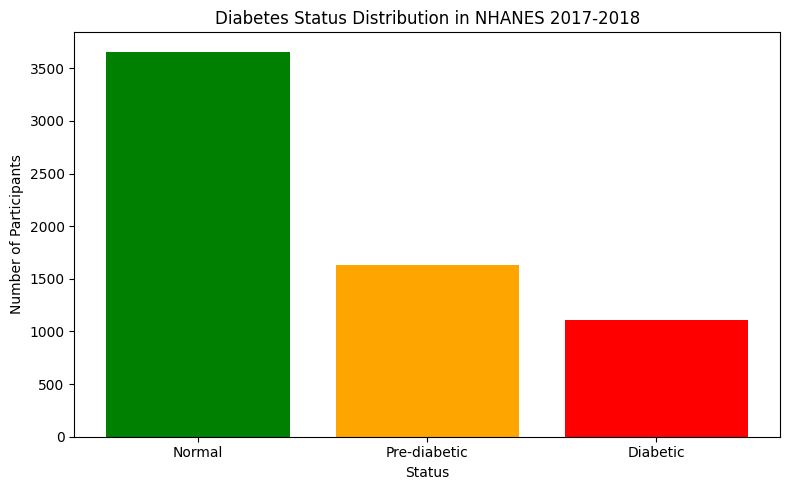

diabetes_status
Normal          3659
Pre-diabetic    1635
Diabetic        1107
Name: count, dtype: int64


In [19]:
# Create diabetes classification based on HbA1c
hba1c_df = dataframes['hba1c'].copy()

def classify_diabetes(hba1c):
    if hba1c < 5.7:
        return 'Normal'
    elif hba1c < 6.5:
        return 'Pre-diabetic'
    else:
        return 'Diabetic'

hba1c_df['diabetes_status'] = hba1c_df['LBXGH'].apply(classify_diabetes)

# Plot
import matplotlib.pyplot as plt
counts = hba1c_df['diabetes_status'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(counts.index, counts.values, color=['green','orange','red'])
plt.title('Diabetes Status Distribution in NHANES 2017-2018')
plt.xlabel('Status')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.savefig('../reports/diabetes_distribution.png')
plt.show()
print(counts)